# Fase 2 — Análisis Estadístico: Ganadería, Agricultura y Pérdida Forestal en México

**Fuentes:**
- Global Forest Watch (MEX.xlsx) — pérdida de cobertura arbórea 2001-2023
- SIAP/DGSIAP — superficie sembrada por cultivo y estado 2001-2023
- SIAP Producción Pecuaria — producción ganadera por estado/municipio 2006-2022 + 2024
- Gobierno de México — deforestación estatal oficial 2001-2023

**Técnicas aplicadas:** Distribuciones paramétricas · Intervalos de confianza · Test de hipótesis · Prueba A/B · Grafos · Reducción de dimensionalidad · Anonimización · Filtro de outliers · Discretización · Eliminación de ruido

## 0. Configuración e imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest, mannwhitneyu, ttest_ind, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE, Isomap
import umap

warnings.filterwarnings('ignore')

OUTPUT_DIR = 'fase2_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PALETTE = {
    'bosque':   '#2E7D32',
    'agricola': '#E65100',
    'ganado':   '#795548',
    'neutro':   '#1565C0',
    'alerta':   '#B71C1C',
    'gris':     '#546E7A',
    'gobierno': '#6A1B9A',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

GFW_THRESHOLD = 30
DATA_DIR = 'Data'
print('Directorios de salida creados:', OUTPUT_DIR)

Directorios de salida creados: fase2_output


## 1. Carga de datos

In [2]:
# --- GFW ---
gfw_estados = pd.read_excel(os.path.join(DATA_DIR, 'MEX.xlsx'),
                             sheet_name='Subnational 1 tree cover loss')
gfw_estados = gfw_estados[gfw_estados['threshold'] == GFW_THRESHOLD].copy()
gfw_nacional = pd.read_excel(os.path.join(DATA_DIR, 'MEX.xlsx'),
                              sheet_name='Country tree cover loss')
gfw_nacional = gfw_nacional[gfw_nacional['threshold'] == GFW_THRESHOLD].copy()

columnas_loss = [c for c in gfw_estados.columns if c.startswith('tc_loss_ha_')]
years_gfw = [int(c.replace('tc_loss_ha_', '')) for c in columnas_loss]
gfw_estados['perdida_total'] = gfw_estados[columnas_loss].sum(axis=1)
gfw_estados['perdida_pct'] = gfw_estados['perdida_total'] / gfw_estados['extent_2000_ha'] * 100

# Serie nacional
loss_nacional = gfw_nacional[columnas_loss].iloc[0].values
serie_nacional = pd.Series(loss_nacional, index=years_gfw, name='perdida_ha')

print(f'GFW estados: {gfw_estados.shape}  |  años: {min(years_gfw)}-{max(years_gfw)}')
print(f'Pérdida acumulada nacional: {serie_nacional.sum():,.0f} ha')

GFW estados: (32, 32)  |  años: 2001-2023
Pérdida acumulada nacional: 4,886,723 ha


In [3]:
# --- Ganadería ---
archivos_ganado = sorted(glob.glob(os.path.join(DATA_DIR, 'Produccion_Ganado', 'cierre_*.csv')))
dfs_ganado = []
for f in archivos_ganado:
    try:
        df = pd.read_csv(f, encoding='latin1')
        dfs_ganado.append(df)
    except Exception as e:
        print(f'  Error {f}: {e}')
df_ganado = pd.concat(dfs_ganado, ignore_index=True)
df_ganado['Nomespecie'] = df_ganado['Nomespecie'].str.strip()
df_ganado['Nomproducto'] = df_ganado['Nomproducto'].str.strip()
df_ganado['Nomestado'] = df_ganado['Nomestado'].str.strip()

años_ganado = sorted(df_ganado['Anio'].unique())
print(f'Ganadería: {df_ganado.shape}  |  años: {años_ganado}')
print(f'Especies: {df_ganado["Nomespecie"].unique()}')
print(f'Nota: 2023 AUSENTE de la base gubernamental')

Ganadería: (559460, 16)  |  años: [np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(nan), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2024.0)]
Especies: <StringArray>
['Abeja', 'Ave', 'Bovino', 'Caprino', 'Ovino', 'Porcino', 'Guajolote', nan]
Length: 8, dtype: str
Nota: 2023 AUSENTE de la base gubernamental


In [4]:
# --- Deforestación oficial gobierno ---
df_gob = pd.read_excel(os.path.join(DATA_DIR, 'Deforestacion_Gobierno',
                                     'deforestacion_estatal_2023.xlsx'))
df_gob['Estado'] = df_gob['Estado'].str.strip()

# Total por año (todos los estados y categorías)
gob_anual = df_gob.groupby('Año')['SuperficieTransicion'].sum().reset_index()
gob_anual.columns = ['año', 'ha_gobierno']

print(f'Gobierno: {df_gob.shape}  |  estados cubiertos: {df_gob["Estado"].nunique()}')
print(f'Categorías destino: {list(df_gob["CategoriaDestino"].unique())}')

Gobierno: (6049, 5)  |  estados cubiertos: 10
Categorías destino: ['Asentamientos humanos', 'Humedales', 'Otros usos', 'Pastizales', 'Tierras Agrícolas']


## 2. Preprocesamiento — Construcción del panel integrado

In [5]:
# Panel ganadero por estado y año
# Nos enfocamos en Bovino/Carne (el principal driver de deforestación)
bovino = df_ganado[(df_ganado['Nomespecie'] == 'Bovino') &
                   (df_ganado['Nomproducto'] == 'Carne')].copy()

ganado_estado = (bovino.groupby(['Anio', 'Nomestado'])
                 .agg(cabezas=('Asacrificado', 'sum'),
                      volumen_ton=('Volumen', 'sum'),
                      valor_mxn=('Valor', 'sum'))
                 .reset_index()
                 .rename(columns={'Anio': 'año', 'Nomestado': 'estado'}))

# GFW en formato largo
gfw_long = gfw_estados.melt(
    id_vars=['subnational1', 'extent_2000_ha', 'perdida_total'],
    value_vars=columnas_loss,
    var_name='año_col', value_name='perdida_ha'
)
gfw_long['año'] = gfw_long['año_col'].str.replace('tc_loss_ha_', '').astype(int)
gfw_long = gfw_long[['subnacional1' if 'subnacional1' in gfw_long.columns
                      else 'subnational1', 'año', 'perdida_ha', 'extent_2000_ha']]
gfw_long = gfw_long.rename(columns={'subnational1': 'estado'})

# Normalizar nombres de estados para merge
def normalizar(s):
    return (s.str.strip()
             .str.replace('á', 'a').str.replace('é', 'e')
             .str.replace('í', 'i').str.replace('ó', 'o')
             .str.replace('ú', 'u').str.replace('ü', 'u')
             .str.lower())

gfw_long['estado_key'] = normalizar(gfw_long['estado'])
ganado_estado['estado_key'] = normalizar(ganado_estado['estado'])

# Panel: ventana común 2006-2022
panel = gfw_long[(gfw_long['año'] >= 2006) & (gfw_long['año'] <= 2022)].merge(
    ganado_estado[['año', 'estado_key', 'cabezas', 'volumen_ton', 'valor_mxn']],
    on=['año', 'estado_key'], how='left'
)
panel = panel.dropna(subset=['cabezas'])

print(f'Panel integrado: {panel.shape}')
print(f'Estados: {panel["estado"].nunique()}  |  años: {sorted(panel["año"].unique())}')
print(f'Valores faltantes:\n{panel[["perdida_ha","cabezas","volumen_ton"]].isna().sum()}')

Panel integrado: (538, 8)
Estados: 32  |  años: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Valores faltantes:
perdida_ha     0
cabezas        0
volumen_ton    0
dtype: int64


## 3. Eliminación de ruido — Suavizado de la serie temporal nacional

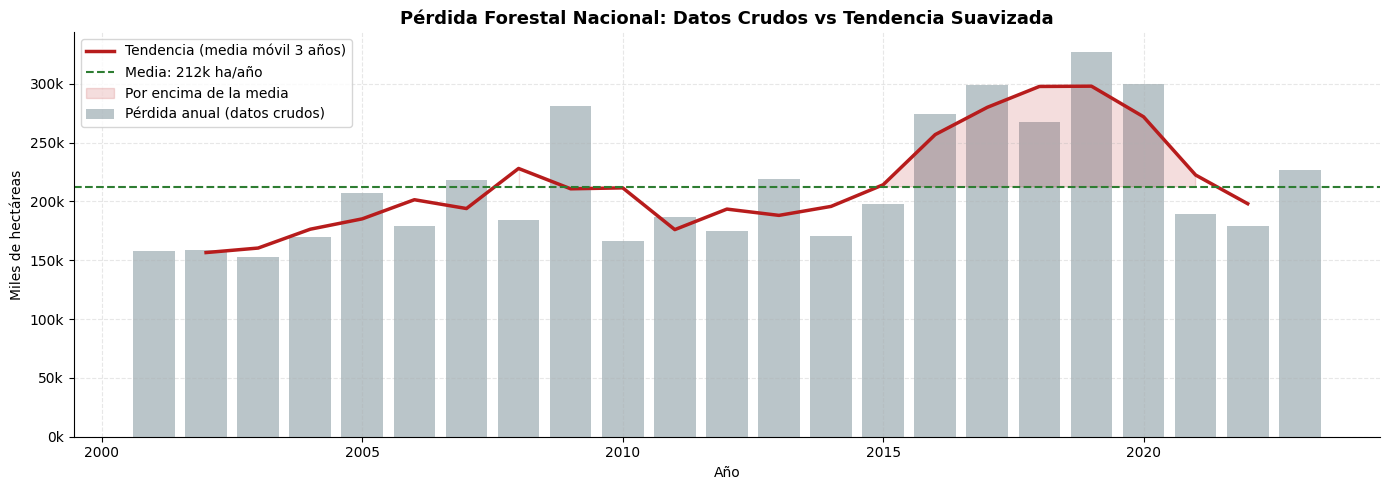

Guardado: F2_01_serie_suavizada.png


In [6]:
# Rolling mean 3 años para separar tendencia de variabilidad climática anual
serie_suavizada = serie_nacional.rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(serie_nacional.index, serie_nacional.values / 1000,
       color=PALETTE['gris'], alpha=0.4, label='Pérdida anual (datos crudos)')
ax.plot(serie_suavizada.index, serie_suavizada.values / 1000,
        color=PALETTE['alerta'], linewidth=2.5, label='Tendencia (media móvil 3 años)')
ax.axhline(serie_nacional.mean() / 1000, color=PALETTE['bosque'],
           linestyle='--', linewidth=1.5, label=f'Media: {serie_nacional.mean()/1000:.0f}k ha/año')
ax.fill_between(serie_suavizada.index, serie_suavizada.values / 1000,
                serie_nacional.mean() / 1000,
                where=serie_suavizada.values > serie_nacional.mean(),
                alpha=0.15, color=PALETTE['alerta'], label='Por encima de la media')
ax.set_title('Pérdida Forestal Nacional: Datos Crudos vs Tendencia Suavizada',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Miles de hectáreas')
ax.set_xlabel('Año')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_01_serie_suavizada.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_01_serie_suavizada.png')

## 4. Filtro de outliers — Detección de años y estados anómalos

=== Outliers temporales (|Z| > 1.5) ===
  2017: 298,788 ha  (Z = 1.64)
  2019: 327,438 ha  (Z = 2.18)
  2020: 299,526 ha  (Z = 1.65)

=== Outliers espaciales (IQR) — 6 estados ===
subnational1  perdida_total  perdida_pct
    Campeche         906743    19.759076
     Chiapas         783374    16.172061
Quintana Roo         599593    15.964344
     Yucatán         522499    17.986611
    Veracruz         496448    16.666359
      Oaxaca         431916     8.550102


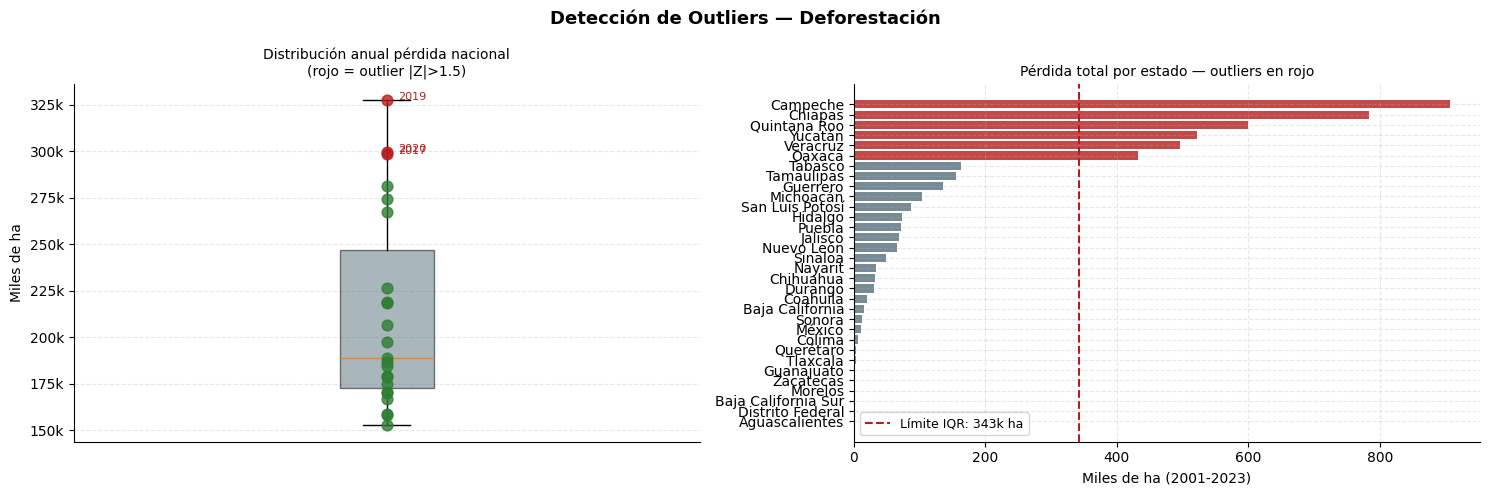

Guardado: F2_02_outliers.png


In [7]:
# --- Outliers temporales (serie nacional) ---
z_nacional = (serie_nacional - serie_nacional.mean()) / serie_nacional.std()
outliers_años = z_nacional[z_nacional.abs() > 1.5]

print('=== Outliers temporales (|Z| > 1.5) ===')
for año, z in outliers_años.items():
    print(f'  {año}: {serie_nacional[año]:,.0f} ha  (Z = {z:.2f})')

# --- Outliers espaciales (pérdida total por estado 2001-2023) ---
q1 = gfw_estados['perdida_total'].quantile(0.25)
q3 = gfw_estados['perdida_total'].quantile(0.75)
iqr = q3 - q1
outliers_estados = gfw_estados[gfw_estados['perdida_total'] > q3 + 1.5 * iqr]

print(f'\n=== Outliers espaciales (IQR) — {len(outliers_estados)} estados ===')
print(outliers_estados[['subnational1', 'perdida_total', 'perdida_pct']]
      .sort_values('perdida_total', ascending=False).to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Detección de Outliers — Deforestación', fontsize=13, fontweight='bold')

# Boxplot + strip temporal
ax = axes[0]
ax.boxplot(serie_nacional.values / 1000, vert=True, patch_artist=True,
           boxprops=dict(facecolor=PALETTE['gris'], alpha=0.5))
for año, val in serie_nacional.items():
    color = PALETTE['alerta'] if abs(z_nacional[año]) > 1.5 else PALETTE['bosque']
    ax.scatter(1, val / 1000, color=color, s=60, alpha=0.8, zorder=5)
    if abs(z_nacional[año]) > 1.5:
        ax.annotate(str(año), (1, val / 1000), xytext=(8, 0),
                    textcoords='offset points', fontsize=8, color=PALETTE['alerta'])
ax.set_title('Distribución anual pérdida nacional\n(rojo = outlier |Z|>1.5)', fontsize=10)
ax.set_ylabel('Miles de ha')
ax.set_xticks([])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# Boxplot por estado
ax2 = axes[1]
colores_est = [PALETTE['alerta'] if est in outliers_estados['subnational1'].values
               else PALETTE['gris']
               for est in gfw_estados.sort_values('perdida_total')['subnational1']]
gfw_sort = gfw_estados.sort_values('perdida_total')
ax2.barh(gfw_sort['subnational1'], gfw_sort['perdida_total'] / 1000,
         color=colores_est, alpha=0.8)
ax2.axvline((q3 + 1.5 * iqr) / 1000, color=PALETTE['alerta'], linestyle='--',
             linewidth=1.5, label=f'Límite IQR: {(q3+1.5*iqr)/1000:.0f}k ha')
ax2.set_title('Pérdida total por estado — outliers en rojo', fontsize=10)
ax2.set_xlabel('Miles de ha (2001-2023)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_02_outliers.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_02_outliers.png')

## 5. Discretización — Clasificación de estados por nivel de riesgo forestal

Distribución de estados por categoría de riesgo:
categoria_riesgo
Bajo        8
Moderado    8
Alto        8
Crítico     8
Name: count, dtype: int64

  Bajo: ['Aguascalientes', 'Baja California Sur', 'Distrito Federal', 'Guanajuato', 'Morelos', 'Querétaro', 'Tlaxcala', 'Zacatecas']
  Moderado: ['Baja California', 'Chihuahua', 'Coahuila', 'Colima', 'Durango', 'México', 'Nayarit', 'Sonora']
  Alto: ['Guerrero', 'Hidalgo', 'Jalisco', 'Michoacán', 'Nuevo León', 'Puebla', 'San Luis Potosí', 'Sinaloa']
  Crítico: ['Campeche', 'Chiapas', 'Oaxaca', 'Quintana Roo', 'Tabasco', 'Tamaulipas', 'Veracruz', 'Yucatán']


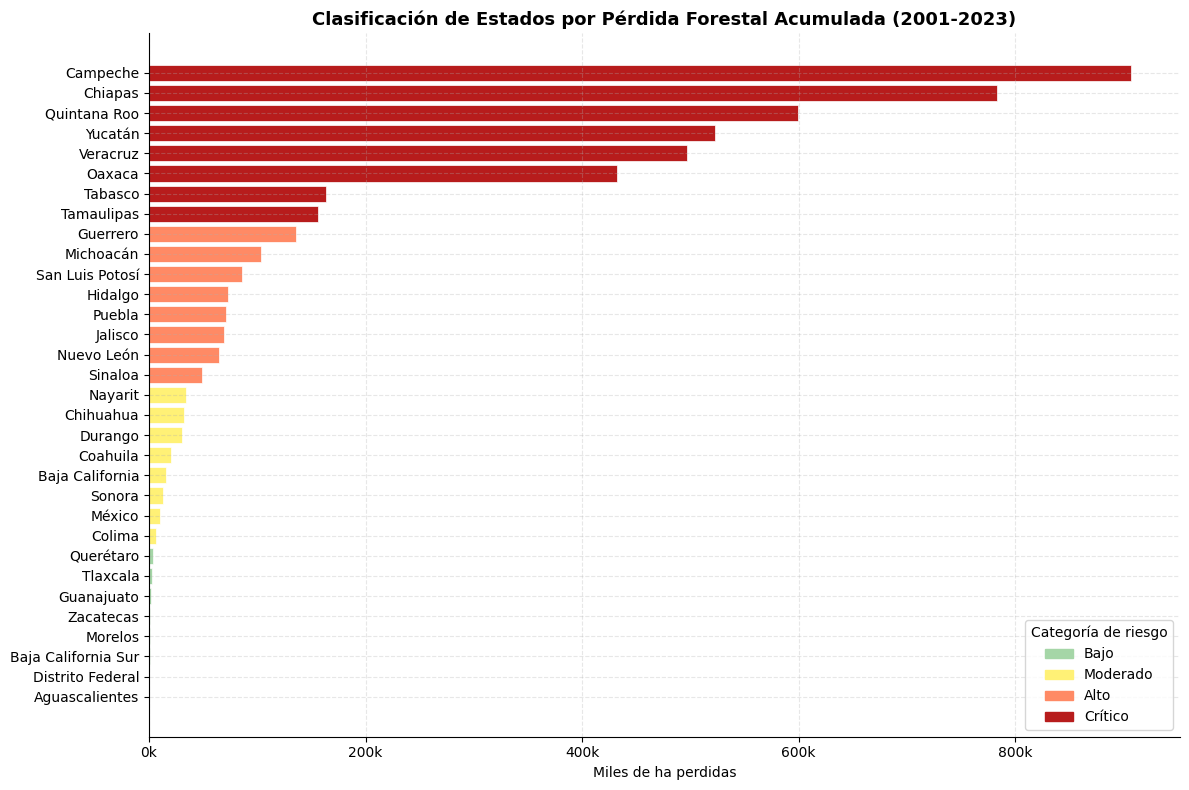

Guardado: F2_03_discretizacion.png


In [8]:
# Discretizar usando percentiles: Crítico / Alto / Moderado / Bajo
bins = gfw_estados['perdida_total'].quantile([0, 0.25, 0.5, 0.75, 1.0]).values
labels = ['Bajo', 'Moderado', 'Alto', 'Crítico']

gfw_estados['categoria_riesgo'] = pd.cut(
    gfw_estados['perdida_total'],
    bins=bins, labels=labels, include_lowest=True
)

print('Distribución de estados por categoría de riesgo:')
print(gfw_estados['categoria_riesgo'].value_counts().sort_index())
print()
for cat in labels:
    estados_cat = gfw_estados[gfw_estados['categoria_riesgo'] == cat]['subnational1'].tolist()
    print(f'  {cat}: {estados_cat}')

# Paleta por categoría
cat_colors = {'Bajo': '#A5D6A7', 'Moderado': '#FFF176', 'Alto': '#FF8A65', 'Crítico': '#B71C1C'}

fig, ax = plt.subplots(figsize=(12, 8))
gfw_sort = gfw_estados.sort_values('perdida_total')
colores_cat = [cat_colors[c] for c in gfw_sort['categoria_riesgo']]
bars = ax.barh(gfw_sort['subnational1'], gfw_sort['perdida_total'] / 1000,
               color=colores_cat, edgecolor='white', linewidth=0.5)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend_patches, title='Categoría de riesgo', loc='lower right')
ax.set_title('Clasificación de Estados por Pérdida Forestal Acumulada (2001-2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Miles de ha perdidas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_03_discretizacion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_03_discretizacion.png')

## 6. Distribuciones paramétricas — Ajuste a la pérdida forestal anual

=== Pruebas de normalidad sobre la pérdida forestal anual ===
Shapiro-Wilk:    W=0.8732  p=0.0074  → No normal
D'Agostino-K²:   K²=3.5398  p=0.1703  → Normal

=== Ajuste a distribuciones paramétricas (KS-test) ===
norm      : KS=0.1969  p=0.2946  params=[np.float64(212466.22), np.float64(51505.69)]
lognorm   : KS=0.1211  p=0.8490  params=[np.float64(0.84), 144436.94, np.float64(49500.03)]
gamma     : KS=0.1467  p=0.6523  params=[np.float64(0.81), np.float64(152559.0), np.float64(67194.32)]
expon     : KS=0.1132  p=0.8979  params=[152559.0, 59907.22]


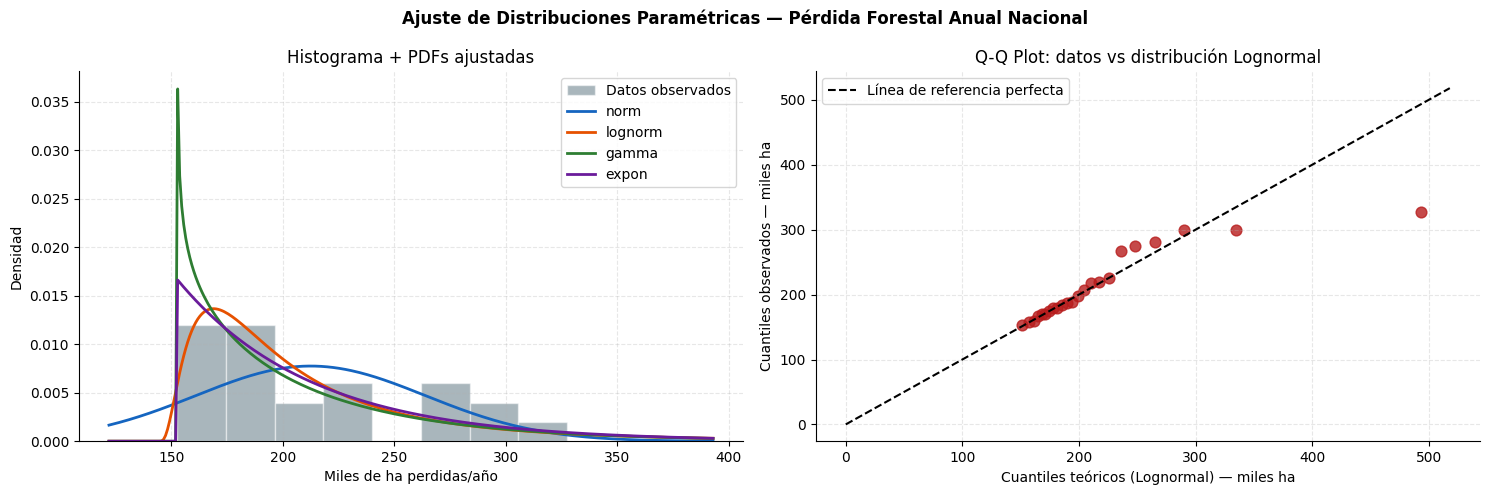

Guardado: F2_04_distribuciones.png


In [9]:
datos = serie_nacional.values

# Pruebas de normalidad
stat_shapiro, p_shapiro = shapiro(datos)
stat_dagostino, p_dagostino = normaltest(datos)
print('=== Pruebas de normalidad sobre la pérdida forestal anual ===')
print(f'Shapiro-Wilk:    W={stat_shapiro:.4f}  p={p_shapiro:.4f}  → {"Normal" if p_shapiro>0.05 else "No normal"}')
print(f"D'Agostino-K²:   K²={stat_dagostino:.4f}  p={p_dagostino:.4f}  → {'Normal' if p_dagostino>0.05 else 'No normal'}")

# Ajuste a distribuciones candidatas
dist_names = ['norm', 'lognorm', 'gamma', 'expon']
dist_params = {}
print('\n=== Ajuste a distribuciones paramétricas (KS-test) ===')
for name in dist_names:
    dist = getattr(stats, name)
    params = dist.fit(datos)
    ks_stat, ks_p = kstest(datos, name, args=params)
    dist_params[name] = params
    print(f'{name:10s}: KS={ks_stat:.4f}  p={ks_p:.4f}  params={[round(p,2) for p in params]}')

# Gráfica: histograma + PDFs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ajuste de Distribuciones Paramétricas — Pérdida Forestal Anual Nacional',
             fontsize=12, fontweight='bold')

x = np.linspace(datos.min() * 0.8, datos.max() * 1.2, 300)
colores_dist = {'norm': '#1565C0', 'lognorm': '#E65100', 'gamma': '#2E7D32', 'expon': '#6A1B9A'}

ax = axes[0]
ax.hist(datos / 1000, bins=8, density=True, color=PALETTE['gris'],
        alpha=0.5, edgecolor='white', label='Datos observados')
for name, params in dist_params.items():
    dist = getattr(stats, name)
    pdf = dist.pdf(x, *params)
    ax.plot(x / 1000, pdf * 1000, color=colores_dist[name], linewidth=2, label=name)
ax.set_xlabel('Miles de ha perdidas/año')
ax.set_ylabel('Densidad')
ax.set_title('Histograma + PDFs ajustadas')
ax.legend()

# Q-Q plot vs lognormal (mejor ajuste esperado)
ax2 = axes[1]
params_ln = dist_params['lognorm']
theoretical = stats.lognorm.ppf(np.linspace(0.01, 0.99, len(datos)), *params_ln)
ax2.scatter(np.sort(theoretical) / 1000, np.sort(datos) / 1000,
            color=PALETTE['alerta'], s=60, alpha=0.8)
lim = max(theoretical.max(), datos.max()) / 1000 * 1.05
ax2.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Línea de referencia perfecta')
ax2.set_xlabel('Cuantiles teóricos (Lognormal) — miles ha')
ax2.set_ylabel('Cuantiles observados — miles ha')
ax2.set_title('Q-Q Plot: datos vs distribución Lognormal')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_04_distribuciones.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_04_distribuciones.png')

## 7. Intervalos de confianza — Tasa anual de deforestación y correlaciones

=== Intervalo de confianza: pérdida forestal anual media (nacional) ===
  Media:       212,466 ha/año
  IC 95%:      [189,693, 235,240] ha
  IC 99%:      [181,513, 243,419] ha



=== IC Bootstrap (n=10,000): correlación Bovino ↔ Pérdida forestal ===
  r observado: 0.1546  (p=0.0003)
  IC 95% bootstrap: [0.0623, 0.2487]


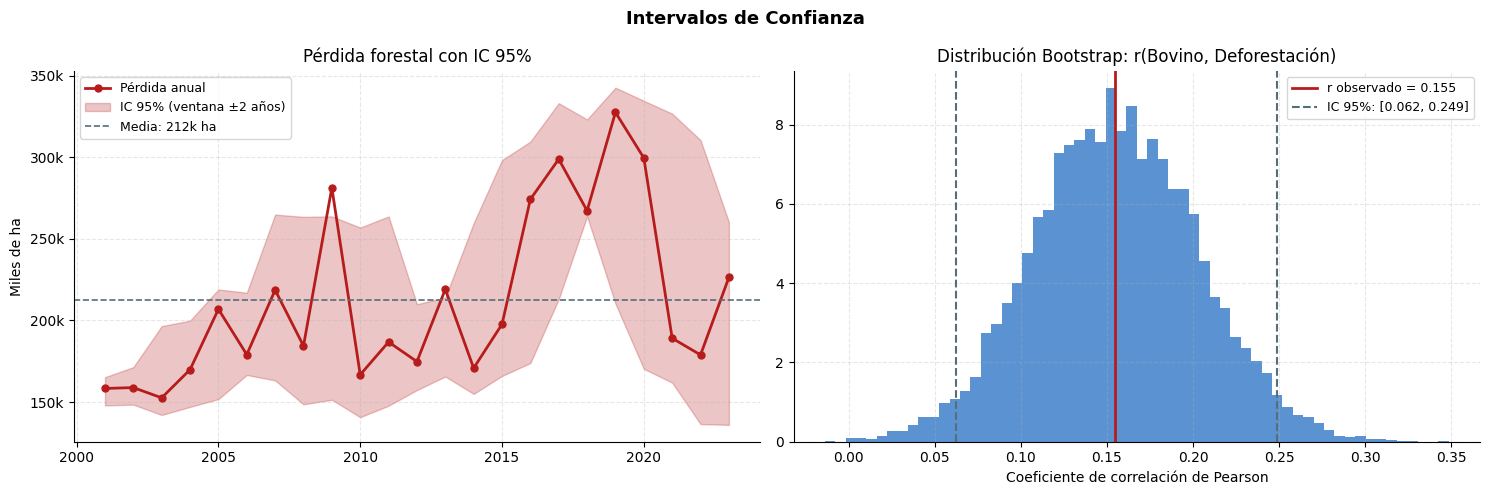

Guardado: F2_05_intervalos_confianza.png


In [10]:
# --- IC paramétrico (t-distribution) sobre la media anual nacional ---
n = len(datos)
media = datos.mean()
se = stats.sem(datos)
ic_95 = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
ic_99 = stats.t.interval(0.99, df=n-1, loc=media, scale=se)

print('=== Intervalo de confianza: pérdida forestal anual media (nacional) ===')
print(f'  Media:       {media:,.0f} ha/año')
print(f'  IC 95%:      [{ic_95[0]:,.0f}, {ic_95[1]:,.0f}] ha')
print(f'  IC 99%:      [{ic_99[0]:,.0f}, {ic_99[1]:,.0f}] ha')

# --- IC bootstrap sobre la correlación Bovino-Deforestación ---
panel_agg = (panel.groupby(['año', 'estado'])
             .agg(perdida_ha=('perdida_ha', 'mean'),
                  cabezas=('cabezas', 'sum'))
             .reset_index())

# Correlación observada
r_obs, p_obs = pearsonr(panel_agg['cabezas'], panel_agg['perdida_ha'])

# Bootstrap 10 000 muestras
np.random.seed(42)
n_boot = 10_000
boot_corrs = []
idx = np.arange(len(panel_agg))
for _ in range(n_boot):
    sample = np.random.choice(idx, size=len(idx), replace=True)
    r_b, _ = pearsonr(panel_agg['cabezas'].iloc[sample],
                      panel_agg['perdida_ha'].iloc[sample])
    boot_corrs.append(r_b)
boot_corrs = np.array(boot_corrs)
ic_boot = np.percentile(boot_corrs, [2.5, 97.5])

print(f'\n=== IC Bootstrap (n=10,000): correlación Bovino ↔ Pérdida forestal ===')
print(f'  r observado: {r_obs:.4f}  (p={p_obs:.4f})')
print(f'  IC 95% bootstrap: [{ic_boot[0]:.4f}, {ic_boot[1]:.4f}]')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Intervalos de Confianza', fontsize=13, fontweight='bold')

ax = axes[0]
años_plot = np.arange(2001, 2024)
# IC por ventana de 5 años (rolling)
ic_low, ic_high = [], []
for yr in años_plot:
    window = serie_nacional[(serie_nacional.index >= yr-2) & (serie_nacional.index <= yr+2)]
    if len(window) >= 3:
        lo, hi = stats.t.interval(0.95, df=len(window)-1,
                                   loc=window.mean(), scale=stats.sem(window))
    else:
        lo, hi = np.nan, np.nan
    ic_low.append(lo)
    ic_high.append(hi)

ax.plot(serie_nacional.index, serie_nacional.values / 1000,
        'o-', color=PALETTE['alerta'], linewidth=2, markersize=5, label='Pérdida anual')
ax.fill_between(años_plot, np.array(ic_low) / 1000, np.array(ic_high) / 1000,
                alpha=0.25, color=PALETTE['alerta'], label='IC 95% (ventana ±2 años)')
ax.axhline(media / 1000, color=PALETTE['gris'], linestyle='--', linewidth=1.2,
           label=f'Media: {media/1000:.0f}k ha')
ax.set_title('Pérdida forestal con IC 95%')
ax.set_ylabel('Miles de ha')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

ax2 = axes[1]
ax2.hist(boot_corrs, bins=60, color=PALETTE['neutro'], alpha=0.7, density=True)
ax2.axvline(r_obs, color=PALETTE['alerta'], linewidth=2, label=f'r observado = {r_obs:.3f}')
ax2.axvline(ic_boot[0], color=PALETTE['gris'], linewidth=1.5, linestyle='--')
ax2.axvline(ic_boot[1], color=PALETTE['gris'], linewidth=1.5, linestyle='--',
            label=f'IC 95%: [{ic_boot[0]:.3f}, {ic_boot[1]:.3f}]')
ax2.set_title('Distribución Bootstrap: r(Bovino, Deforestación)')
ax2.set_xlabel('Coeficiente de correlación de Pearson')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_05_intervalos_confianza.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_05_intervalos_confianza.png')

## 8. Test de hipótesis — ¿La producción bovina está correlacionada con la deforestación?

In [11]:
print('=' * 65)
print('TEST DE HIPÓTESIS 1')
print('H₀: No existe correlación entre cabezas de ganado bovino')
print('    y pérdida forestal por estado-año')
print('H₁: Existe correlación positiva significativa (α=0.05)')
print('=' * 65)

x_ganado = panel_agg['cabezas'].values
y_forestal = panel_agg['perdida_ha'].values

r_pearson, p_pearson = pearsonr(x_ganado, y_forestal)
r_spearman, p_spearman = spearmanr(x_ganado, y_forestal)

print(f'\n  Pearson:   r={r_pearson:.4f}  p={p_pearson:.4f}  → {"Rechazar H₀" if p_pearson<0.05 else "No rechazar H₀"}')
print(f'  Spearman:  r={r_spearman:.4f}  p={p_spearman:.4f}  → {"Rechazar H₀" if p_spearman<0.05 else "No rechazar H₀"}')

print('\n---')
print('TEST DE HIPÓTESIS 2')
print('H₀: La pérdida forestal media 2006-2013 = 2014-2022')
print('H₁: Existe diferencia significativa entre períodos')
print('---')

periodo1 = serie_nacional[(serie_nacional.index >= 2006) & (serie_nacional.index <= 2013)].values
periodo2 = serie_nacional[(serie_nacional.index >= 2014) & (serie_nacional.index <= 2022)].values

t_stat, p_ttest = ttest_ind(periodo1, periodo2)
u_stat, p_mw = mannwhitneyu(periodo1, periodo2, alternative='two-sided')

print(f'  Período 1 (2006-2013): media={periodo1.mean()/1000:.1f}k ha/año  n={len(periodo1)}')
print(f'  Período 2 (2014-2022): media={periodo2.mean()/1000:.1f}k ha/año  n={len(periodo2)}')
print(f'\n  t-test:          t={t_stat:.4f}  p={p_ttest:.4f}  → {"Rechazar H₀" if p_ttest<0.05 else "No rechazar H₀"}')
print(f'  Mann-Whitney U:  U={u_stat:.0f}     p={p_mw:.4f}  → {"Rechazar H₀" if p_mw<0.05 else "No rechazar H₀"}')

print('\n---')
print('TEST DE HIPÓTESIS 3: Gobierno vs Satélite')
print('H₀: La deforestación oficial ≥ 80% de lo reportado por GFW')
print('H₁: El gobierno subreporta significativamente (< 80% de GFW)')
print('---')

# Comparar series 2001-2023
serie_gfw = pd.Series(loss_nacional, index=years_gfw)
gob_serie = gob_anual.set_index('año')['ha_gobierno']
años_comunes = [y for y in years_gfw if y in gob_serie.index]
ratio = gob_serie[años_comunes].values / serie_gfw[años_comunes].values

print(f'  Ratio gobierno/GFW promedio: {ratio.mean():.2%}')
print(f'  Rango: {ratio.min():.2%} — {ratio.max():.2%}')
print(f'  Año de mayor discrepancia: GFW 2019 = {serie_gfw[2019]/1000:.1f}k ha  '
      f'vs Gobierno = {gob_serie.get(2019, 0)/1000:.1f}k ha  '
      f'(ratio={gob_serie.get(2019,0)/serie_gfw[2019]:.1%})')

TEST DE HIPÓTESIS 1
H₀: No existe correlación entre cabezas de ganado bovino
    y pérdida forestal por estado-año
H₁: Existe correlación positiva significativa (α=0.05)

  Pearson:   r=0.1546  p=0.0003  → Rechazar H₀
  Spearman:  r=0.2844  p=0.0000  → Rechazar H₀

---
TEST DE HIPÓTESIS 2
H₀: La pérdida forestal media 2006-2013 = 2014-2022
H₁: Existe diferencia significativa entre períodos
---
  Período 1 (2006-2013): media=201.3k ha/año  n=8
  Período 2 (2014-2022): media=244.8k ha/año  n=9

  t-test:          t=-1.7524  p=0.1001  → No rechazar H₀
  Mann-Whitney U:  U=21     p=0.1672  → No rechazar H₀

---
TEST DE HIPÓTESIS 3: Gobierno vs Satélite
H₀: La deforestación oficial ≥ 80% de lo reportado por GFW
H₁: El gobierno subreporta significativamente (< 80% de GFW)
---
  Ratio gobierno/GFW promedio: 69.69%
  Rango: 31.89% — 112.69%
  Año de mayor discrepancia: GFW 2019 = 327.4k ha  vs Gobierno = 104.4k ha  (ratio=31.9%)


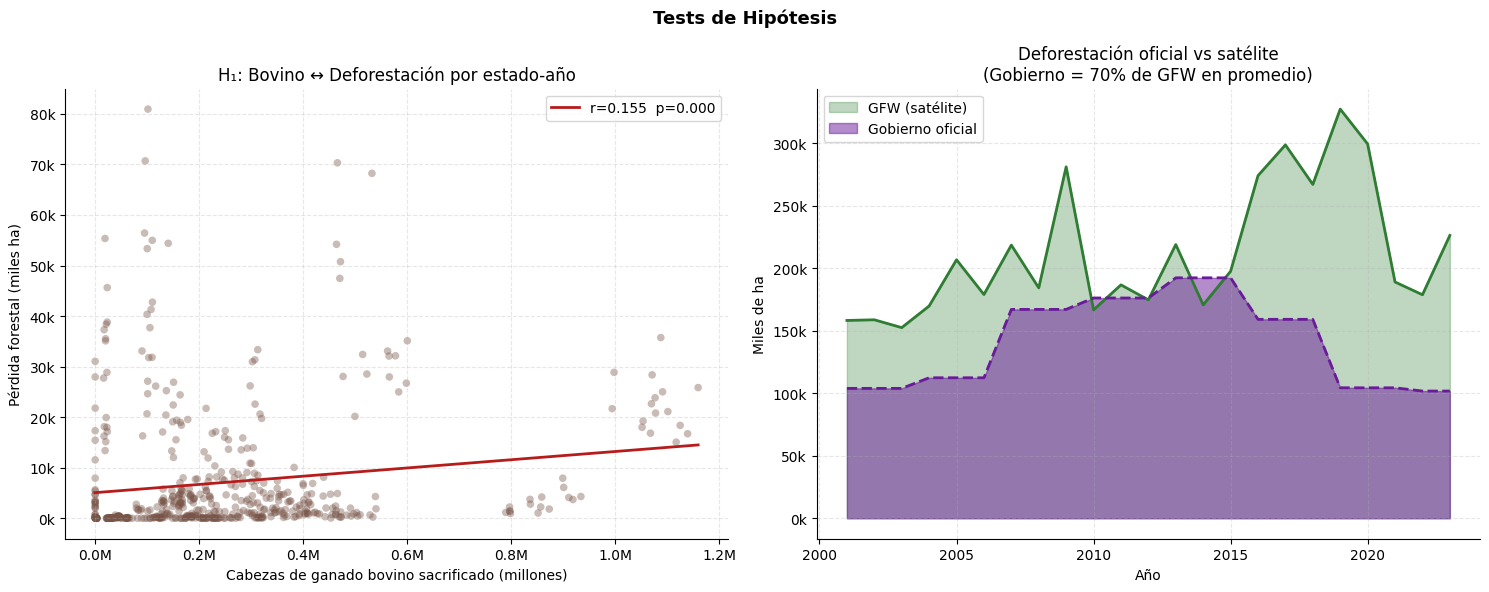

Guardado: F2_06_tests_hipotesis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Tests de Hipótesis', fontsize=13, fontweight='bold')

# Scatter: Bovino vs Deforestación
ax = axes[0]
ax.scatter(x_ganado / 1e6, y_forestal / 1000,
           color=PALETTE['ganado'], alpha=0.4, s=30, edgecolors='none')
# Línea de regresión
m, b = np.polyfit(x_ganado, y_forestal, 1)
x_line = np.linspace(x_ganado.min(), x_ganado.max(), 100)
ax.plot(x_line / 1e6, (m * x_line + b) / 1000,
        color=PALETTE['alerta'], linewidth=2,
        label=f'r={r_pearson:.3f}  p={p_pearson:.3f}')
ax.set_xlabel('Cabezas de ganado bovino sacrificado (millones)')
ax.set_ylabel('Pérdida forestal (miles ha)')
ax.set_title('H₁: Bovino ↔ Deforestación por estado-año')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# Comparación gobierno vs GFW
ax2 = axes[1]
años_c = sorted(años_comunes)
ax2.fill_between(años_c, serie_gfw[años_c].values / 1000, 0,
                 alpha=0.3, color=PALETTE['bosque'], label='GFW (satélite)')
ax2.plot(años_c, serie_gfw[años_c].values / 1000,
         color=PALETTE['bosque'], linewidth=2)
ax2.fill_between(años_c, gob_serie[años_c].values / 1000, 0,
                 alpha=0.5, color=PALETTE['gobierno'], label='Gobierno oficial')
ax2.plot(años_c, gob_serie[años_c].values / 1000,
         color=PALETTE['gobierno'], linewidth=2, linestyle='--')
ax2.set_title(f'Deforestación oficial vs satélite\n(Gobierno = {ratio.mean():.0%} de GFW en promedio)')
ax2.set_ylabel('Miles de ha')
ax2.set_xlabel('Año')
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_06_tests_hipotesis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_06_tests_hipotesis.png')

## 9. Prueba A/B — ¿Los estados con alta ganadería pierden más bosque?

PRUEBA A/B
Grupo A: Estados con ≥ mediana de cabezas bovinas sacrificadas
Grupo B: Estados con < mediana de cabezas bovinas sacrificadas
H₀: pérdida forestal media(A) = media(B)
H₁: pérdida forestal media(A) > media(B)
  Grupo A: 17 estados  media=7,136 ha/año
  Grupo B: 15 estados  media=6,869 ha/año
  Diferencia: 267 ha/año más en grupo A

  t-test (Welch):    t=0.0660  p=0.9478
  Mann-Whitney U:    U=166  p(una cola)=0.0756

  Conclusión: No rechazar H₀


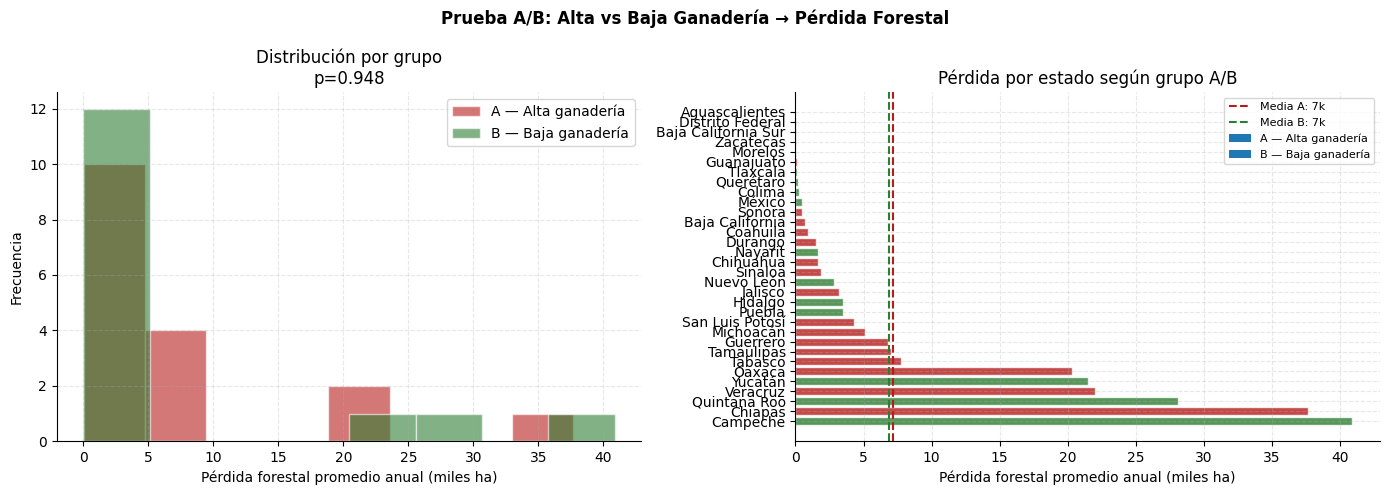

Guardado: F2_07_prueba_ab.png


In [13]:
# Clasificar estados en alta vs baja intensidad ganadera
# Métrica: cabezas bovinas promedio anual por estado (2006-2022)
intensidad_ganadera = (ganado_estado.groupby('estado_key')['cabezas']
                       .mean().reset_index()
                       .rename(columns={'cabezas': 'cabezas_promedio'}))

mediana_cabezas = intensidad_ganadera['cabezas_promedio'].median()
intensidad_ganadera['grupo_ab'] = np.where(
    intensidad_ganadera['cabezas_promedio'] >= mediana_cabezas,
    'A — Alta ganadería', 'B — Baja ganadería'
)

# Pérdida forestal promedio anual por estado
perdida_estado_media = (panel_agg.groupby('estado')['perdida_ha'].mean()
                        .reset_index()
                        .rename(columns={'perdida_ha': 'perdida_media'}))
perdida_estado_media['estado_key'] = normalizar(perdida_estado_media['estado'])

ab_df = intensidad_ganadera.merge(perdida_estado_media, on='estado_key', how='inner')

grupo_a = ab_df[ab_df['grupo_ab'] == 'A — Alta ganadería']['perdida_media']
grupo_b = ab_df[ab_df['grupo_ab'] == 'B — Baja ganadería']['perdida_media']

t_ab, p_ab = ttest_ind(grupo_a, grupo_b)
u_ab, p_mw_ab = mannwhitneyu(grupo_a, grupo_b, alternative='greater')

print('=' * 65)
print('PRUEBA A/B')
print('Grupo A: Estados con ≥ mediana de cabezas bovinas sacrificadas')
print('Grupo B: Estados con < mediana de cabezas bovinas sacrificadas')
print('H₀: pérdida forestal media(A) = media(B)')
print('H₁: pérdida forestal media(A) > media(B)')
print('=' * 65)
print(f'  Grupo A: {len(grupo_a)} estados  media={grupo_a.mean():,.0f} ha/año')
print(f'  Grupo B: {len(grupo_b)} estados  media={grupo_b.mean():,.0f} ha/año')
print(f'  Diferencia: {grupo_a.mean()-grupo_b.mean():,.0f} ha/año más en grupo A')
print(f'\n  t-test (Welch):    t={t_ab:.4f}  p={p_ab:.4f}')
print(f'  Mann-Whitney U:    U={u_ab:.0f}  p(una cola)={p_mw_ab:.4f}')
print(f'\n  Conclusión: {"Rechazar H₀ — diferencia estadísticamente significativa" if p_ab<0.05 else "No rechazar H₀"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prueba A/B: Alta vs Baja Ganadería → Pérdida Forestal', fontsize=12, fontweight='bold')

ax = axes[0]
colores_ab = {'A — Alta ganadería': PALETTE['alerta'], 'B — Baja ganadería': PALETTE['bosque']}
for grupo, color in colores_ab.items():
    vals = ab_df[ab_df['grupo_ab'] == grupo]['perdida_media']
    ax.hist(vals / 1000, bins=8, alpha=0.6, color=color, label=grupo, edgecolor='white')
ax.set_xlabel('Pérdida forestal promedio anual (miles ha)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución por grupo\np={p_ab:.3f}')
ax.legend()

ax2 = axes[1]
ab_df_sorted = ab_df.sort_values('perdida_media', ascending=False)
colores_bar = [colores_ab[g] for g in ab_df_sorted['grupo_ab']]
ax2.barh(ab_df_sorted['estado'], ab_df_sorted['perdida_media'] / 1000,
         color=colores_bar, alpha=0.8, edgecolor='white')
for grupo, color in colores_ab.items():
    ax2.barh([], [], color=color, alpha=0.8, label=grupo)
ax2.axvline(grupo_a.mean() / 1000, color=PALETTE['alerta'], linestyle='--', linewidth=1.5,
            label=f'Media A: {grupo_a.mean()/1000:.0f}k')
ax2.axvline(grupo_b.mean() / 1000, color=PALETTE['bosque'], linestyle='--', linewidth=1.5,
            label=f'Media B: {grupo_b.mean()/1000:.0f}k')
ax2.legend(fontsize=8)
ax2.set_xlabel('Pérdida forestal promedio anual (miles ha)')
ax2.set_title('Pérdida por estado según grupo A/B')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_07_prueba_ab.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_07_prueba_ab.png')

## 10. Grafos — Red de correlación entre estados

Grafo: 32 nodos  35 aristas (umbral r>0.6)


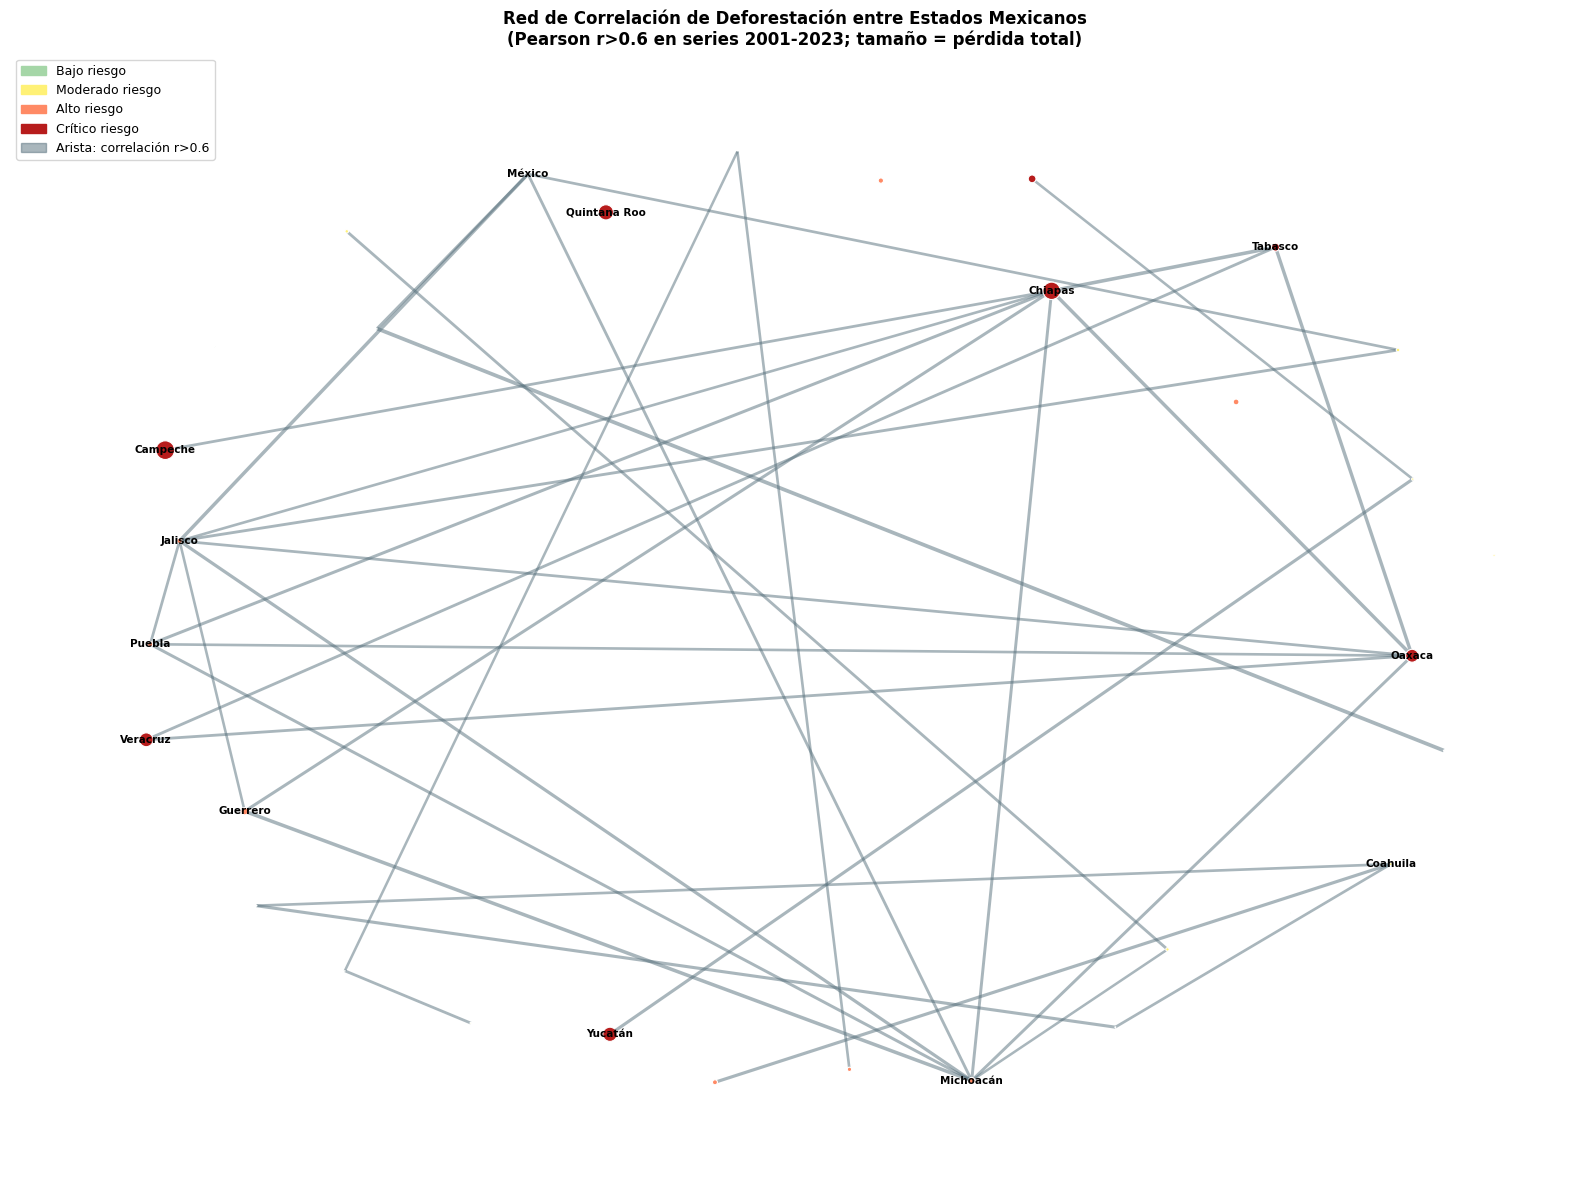

Guardado: F2_08_grafo_correlacion.png

Métricas del grafo:
  Densidad: 0.0706
  Componentes conexas: 10
  Top 5 por centralidad de grado: [('Chiapas', 0.22580645161290322), ('Jalisco', 0.22580645161290322), ('Michoacán', 0.22580645161290322), ('Oaxaca', 0.1935483870967742), ('México', 0.12903225806451613)]


In [14]:
# Construir matriz de correlación: serie temporal de pérdida forestal por estado (2001-2023)
# Cada estado es un nodo; arista si la correlación entre sus series temporales > umbral

matriz_estados = gfw_estados.set_index('subnational1')[columnas_loss].T
matriz_estados.index = years_gfw
corr_matrix = matriz_estados.corr(method='pearson')

UMBRAL = 0.6

G = nx.Graph()
estados_list = corr_matrix.columns.tolist()
G.add_nodes_from(estados_list)

for i, e1 in enumerate(estados_list):
    for j, e2 in enumerate(estados_list):
        if i < j:
            r = corr_matrix.loc[e1, e2]
            if r > UMBRAL:
                G.add_edge(e1, e2, weight=r)

print(f'Grafo: {G.number_of_nodes()} nodos  {G.number_of_edges()} aristas (umbral r>{UMBRAL})')

# Categoría de riesgo para colorear nodos
riesgo_dict = gfw_estados.set_index('subnational1')['categoria_riesgo'].to_dict()
cat_colors_node = {'Bajo': '#A5D6A7', 'Moderado': '#FFF176', 'Alto': '#FF8A65', 'Crítico': '#B71C1C'}
node_colors = [cat_colors_node.get(str(riesgo_dict.get(n, 'Bajo')), '#90CAF9') for n in G.nodes()]

# Tamaño del nodo proporcional a pérdida total
perdida_dict = gfw_estados.set_index('subnational1')['perdida_total'].to_dict()
node_sizes = [perdida_dict.get(n, 1) / 5000 for n in G.nodes()]

# Grosor de arista proporcional a correlación
edge_weights = [G[u][v]['weight'] * 3 for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=2.5)

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_weights,
                       edge_color=PALETTE['gris'], alpha=0.5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, edgecolors='white', linewidths=0.8)

# Labels solo para nodos con muchas conexiones o tamaño grande
grado = dict(G.degree())
labels = {n: n for n in G.nodes() if grado[n] >= 3 or perdida_dict.get(n, 0) > 200000}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7.5, font_weight='bold')

legend_patches = ([mpatches.Patch(color=v, label=f'{k} riesgo') for k, v in cat_colors_node.items()] +
                  [mpatches.Patch(color=PALETTE['gris'], alpha=0.5,
                                  label=f'Arista: correlación r>{UMBRAL}')])
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title(f'Red de Correlación de Deforestación entre Estados Mexicanos\n'
             f'(Pearson r>{UMBRAL} en series 2001-2023; tamaño = pérdida total)',
             fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_08_grafo_correlacion.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: F2_08_grafo_correlacion.png')

# Métricas del grafo
print(f'\nMétricas del grafo:')
print(f'  Densidad: {nx.density(G):.4f}')
if nx.is_connected(G):
    print(f'  Diámetro: {nx.diameter(G)}')
componentes = list(nx.connected_components(G))
print(f'  Componentes conexas: {len(componentes)}')
centralidad = nx.degree_centrality(G)
top_central = sorted(centralidad.items(), key=lambda x: -x[1])[:5]
print(f'  Top 5 por centralidad de grado: {top_central}')

## 11. Reducción de dimensionalidad — Con variables ganaderas añadidas

In [15]:
# Construir matriz de características por estado:
# Deforestación + ganadería (ventana 2006-2022)

# Pérdida forestal por año (2006-2022) para cada estado
cols_loss_06_22 = [f'tc_loss_ha_{y}' for y in range(2006, 2023)]
df_loss_estados = gfw_estados[['subnational1'] + cols_loss_06_22].copy()
df_loss_estados = df_loss_estados.rename(
    columns={f'tc_loss_ha_{y}': f'loss_{y}' for y in range(2006, 2023)}
)
df_loss_estados['estado_key'] = normalizar(df_loss_estados['subnational1'])

# Ganadería bovino por año por estado
ganado_pivot = (ganado_estado[(ganado_estado['año'] >= 2006) & (ganado_estado['año'] <= 2022)]
                .pivot_table(index='estado_key', columns='año', values='cabezas', aggfunc='sum')
                .fillna(0))
ganado_pivot.columns = [f'bovino_{y}' for y in ganado_pivot.columns]
ganado_pivot = ganado_pivot.reset_index()

# Merge por clave normalizada
features_df = df_loss_estados.merge(ganado_pivot, on='estado_key', how='inner')
features_df = features_df.dropna()

estado_labels = features_df['subnational1'].values
riesgo_labels = np.array([str(riesgo_dict.get(e, 'Bajo')) for e in estado_labels])

feature_cols = [c for c in features_df.columns if c.startswith('loss_') or c.startswith('bovino_')]
X = features_df[feature_cols].values.astype(float)
X_scaled = StandardScaler().fit_transform(X)

print(f'Matriz de características: {X_scaled.shape}  '
      f'({len([c for c in feature_cols if c.startswith("loss_")])} loss + '
      f'{len([c for c in feature_cols if c.startswith("bovino_")])} bovino)')
print(f'Estados en la reducción: {len(estado_labels)}')
print(f'Categorías: {np.unique(riesgo_labels)}')

Matriz de características: (32, 34)  (17 loss + 17 bovino)
Estados en la reducción: 32
Categorías: ['Alto' 'Bajo' 'Crítico' 'Moderado']


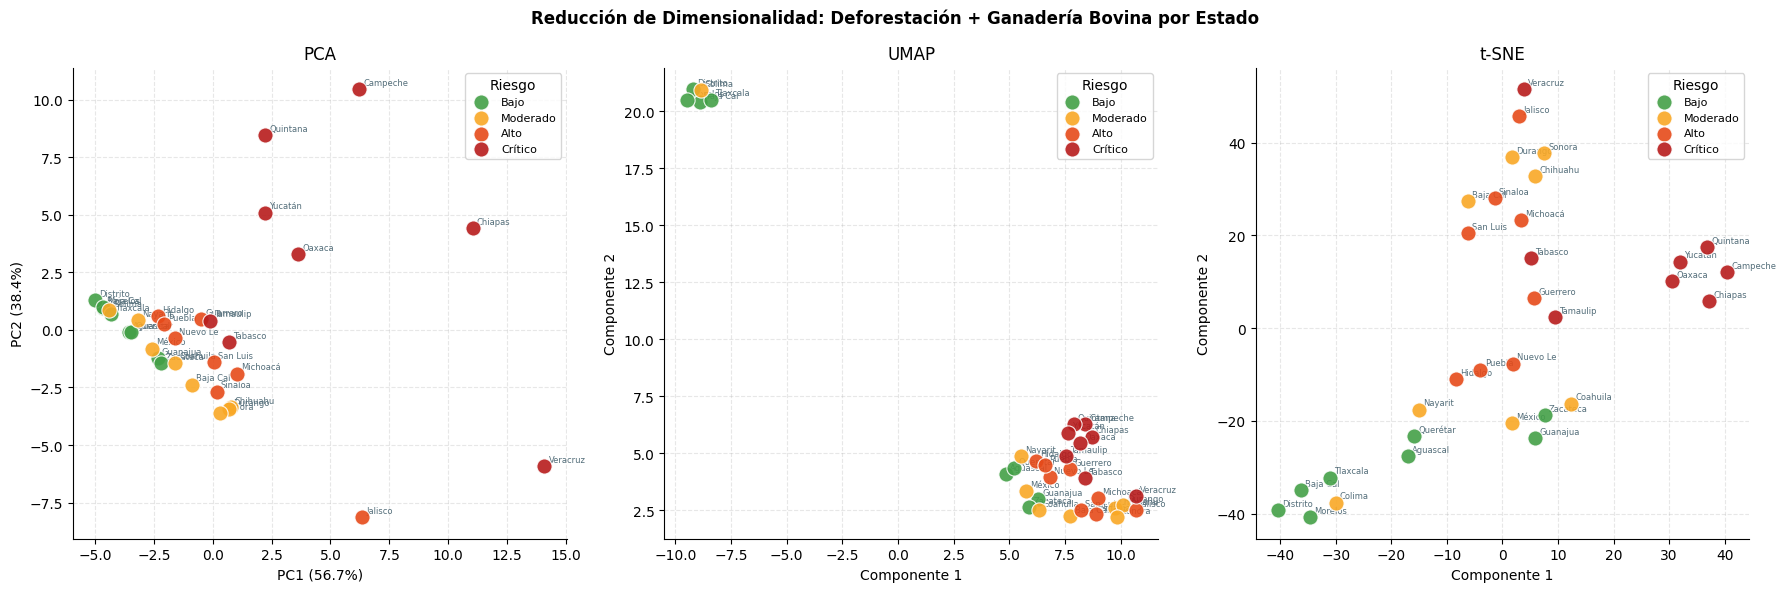

Guardado: F2_09_reduccion_dim.png
PCA varianza explicada: PC1=56.7%  PC2=38.4%


In [16]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# UMAP
reducer_umap = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=0.3)
X_umap = reducer_umap.fit_transform(X_scaled)

# t-SNE (con perplexity pequeña dado n pequeño)
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(X_scaled)-1))
X_tsne = tsne.fit_transform(X_scaled)

cat_colors_dr = {'Bajo': '#43A047', 'Moderado': '#F9A825', 'Alto': '#E64A19', 'Crítico': '#B71C1C'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Reducción de Dimensionalidad: Deforestación + Ganadería Bovina por Estado',
             fontsize=12, fontweight='bold')

for ax, X_red, titulo in zip(axes,
                              [X_pca, X_umap, X_tsne],
                              ['PCA', 'UMAP', 't-SNE']):
    for cat, color in cat_colors_dr.items():
        mask = riesgo_labels == cat
        ax.scatter(X_red[mask, 0], X_red[mask, 1],
                   color=color, s=120, alpha=0.9, edgecolors='white',
                   linewidth=0.8, label=cat, zorder=5)
    for i, est in enumerate(estado_labels):
        ax.annotate(est[:8], (X_red[i, 0], X_red[i, 1]),
                    fontsize=6, xytext=(3, 3), textcoords='offset points',
                    color=PALETTE['gris'])
    if titulo == 'PCA':
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    else:
        ax.set_xlabel('Componente 1')
        ax.set_ylabel('Componente 2')
    ax.set_title(titulo)
    ax.legend(fontsize=8, title='Riesgo')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_09_reduccion_dim.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: F2_09_reduccion_dim.png')
print(f'PCA varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}')

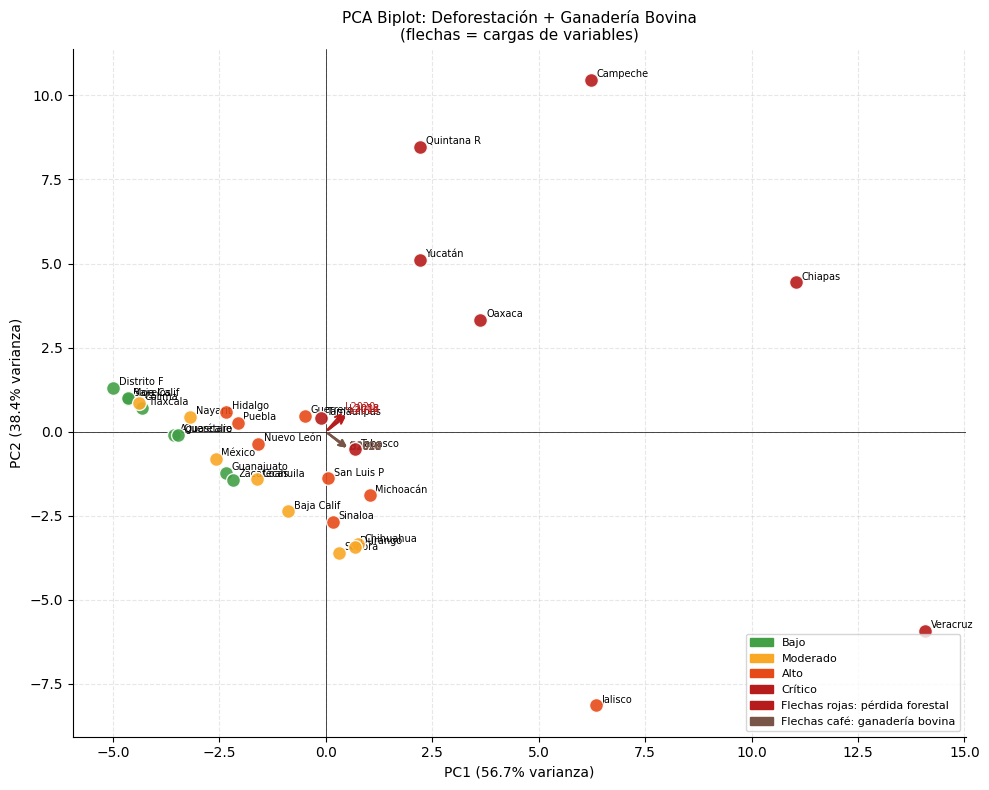

Guardado: F2_10_pca_biplot.png


In [17]:
# Biplot PCA: qué variables impulsan cada componente
loadings = pca.components_.T

fig, ax = plt.subplots(figsize=(10, 8))
for cat, color in cat_colors_dr.items():
    mask = riesgo_labels == cat
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=color, s=100, alpha=0.9, edgecolors='white', label=cat, zorder=5)
for i, est in enumerate(estado_labels):
    ax.annotate(est[:10], (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, xytext=(4, 2), textcoords='offset points')

# Flechas de loading (solo algunos años representativos)
scale = 3.0
for i, feat in enumerate(feature_cols):
    # Extraer año de forma robusta (puede ser 'loss_2008' o 'bovino_2008.0')
    yr_str = feat.split('_')[-1].split('.')[0]
    try:
        yr = int(yr_str)
    except ValueError:
        continue
    if yr % 4 == 0:
        color_arrow = PALETTE['alerta'] if feat.startswith('loss') else PALETTE['ganado']
        ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color_arrow, lw=1.5))
        label = f'L{yr}' if feat.startswith('loss') else f'B{yr}'
        ax.text(loadings[i, 0]*scale*1.05, loadings[i, 1]*scale*1.05,
                label, fontsize=7, color=color_arrow)

loss_patch = mpatches.Patch(color=PALETTE['alerta'], label='Flechas rojas: pérdida forestal')
bov_patch  = mpatches.Patch(color=PALETTE['ganado'], label='Flechas café: ganadería bovina')
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors_dr.items()]
ax.legend(handles=handles + [loss_patch, bov_patch], fontsize=8, loc='lower right')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('PCA Biplot: Deforestación + Ganadería Bovina\n(flechas = cargas de variables)', fontsize=11)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_10_pca_biplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_10_pca_biplot.png')

## 12. Anonimización — k-anonimato en datos municipales ganaderos

=== Demostración de k-anonimato (k=5) ===
Registros originales (nivel municipio, 2019 Bovino Carne): 2396
Registros anonimizados:                                     2396
Estados suprimidos a "Agrupado":   0
Reducción de granularidad:         0.0%

Antes — municipios Tabasco:
Nomestado Nommunicipio    volumen       valor
  Tabasco     Balancán  11968.938  818870.772
  Tabasco       Centla   2634.902   176643.83
  Tabasco       Centro   6285.732  432646.934
  Tabasco   Comalcalco   1746.545  134099.725

Después — Tabasco k-anonimizado:


Nomestado Nommunicipio   volumen      valor  anonimizado
  Tabasco     Balancán 11968.938 818870.772        False
  Tabasco       Centla  2634.902 176643.830        False
  Tabasco       Centro  6285.732 432646.934        False
  Tabasco   Comalcalco  1746.545 134099.725        False


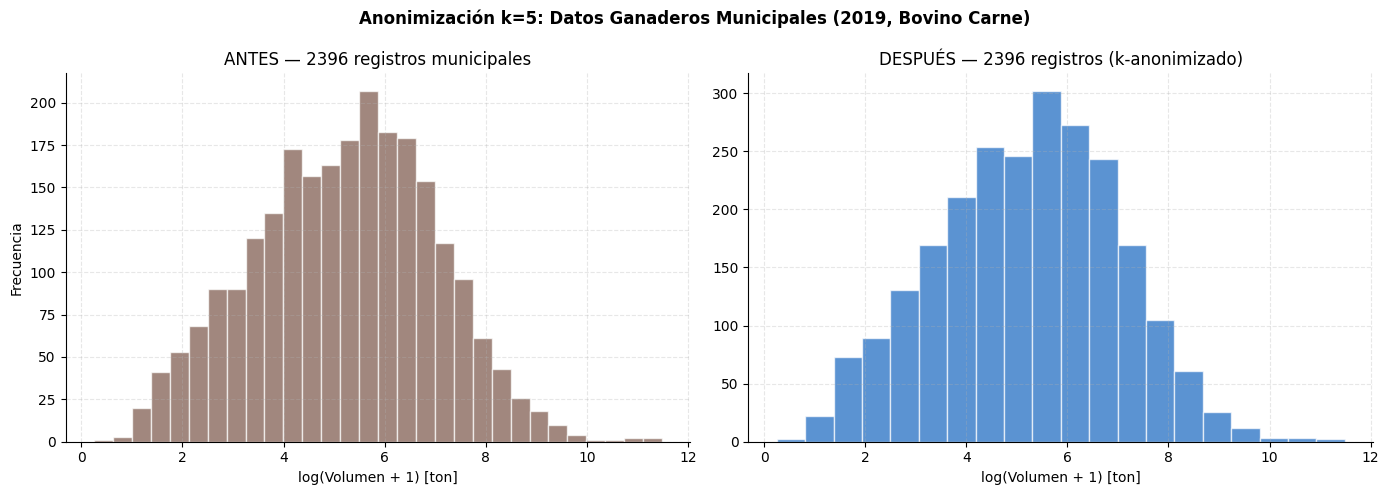

Guardado: F2_11_anonimizacion.png


In [18]:
# Los datos llegan a nivel municipio — potencialmente identificables
# Aplicamos k-anonimato: agrupar municipios con pocos registros por estado

K = 5  # cada estado debe tener >= K municipios visibles

df_muni = df_ganado[(df_ganado['Nomespecie'] == 'Bovino') &
                    (df_ganado['Nomproducto'] == 'Carne') &
                    (df_ganado['Anio'] == 2019)].copy()

# Versión cruda (identificable a nivel municipio)
df_crudo = (df_muni.groupby(['Nomestado', 'Nommunicipio'])
            .agg(volumen=('Volumen', 'sum'), valor=('Valor', 'sum'))
            .reset_index())

# Versión k-anonimizada: iteración explícita para evitar problemas de groupby con pandas 2.x
registros_anon = []
for estado, grupo in df_muni.groupby('Nomestado'):
    municipios_unicos = grupo['Nommunicipio'].nunique()
    if municipios_unicos < K:
        registros_anon.append({
            'Nomestado': estado,
            'Nommunicipio': f'Agrupados (n={municipios_unicos}<{K})',
            'volumen': float(grupo['Volumen'].sum()),
            'valor': float(grupo['Valor'].sum()),
            'anonimizado': True
        })
    else:
        por_muni = (grupo.groupby('Nommunicipio')
                    .agg(volumen=('Volumen', 'sum'), valor=('Valor', 'sum'))
                    .reset_index())
        por_muni.insert(0, 'Nomestado', estado)
        por_muni['anonimizado'] = False
        registros_anon.extend(por_muni.to_dict('records'))

df_anon = pd.DataFrame(registros_anon)

print(f'=== Demostración de k-anonimato (k={K}) ===')
print(f'Registros originales (nivel municipio, 2019 Bovino Carne): {len(df_crudo)}')
print(f'Registros anonimizados:                                     {len(df_anon)}')
print(f'Estados suprimidos a "Agrupado":   {df_anon["anonimizado"].sum()}')
print(f'Reducción de granularidad:         {(1 - len(df_anon)/len(df_crudo))*100:.1f}%')

print(f'\nAntes — municipios Tabasco:')
print(df_crudo[df_crudo['Nomestado'] == 'Tabasco'].head(4).to_string(index=False))
print(f'\nDespués — Tabasco k-anonimizado:')
print(df_anon[df_anon['Nomestado'] == 'Tabasco'].head(4).to_string(index=False))

# Visualización
vol_crudo = pd.to_numeric(df_crudo['volumen'], errors='coerce').dropna().values
vol_anon  = pd.to_numeric(df_anon['volumen'],  errors='coerce').dropna().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Anonimización k={K}: Datos Ganaderos Municipales (2019, Bovino Carne)',
             fontsize=12, fontweight='bold')

axes[0].hist(np.log1p(vol_crudo), bins=30, color=PALETTE['ganado'], alpha=0.7, edgecolor='white')
axes[0].set_title(f'ANTES — {len(df_crudo)} registros municipales')
axes[0].set_xlabel('log(Volumen + 1) [ton]')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(vol_anon), bins=20, color=PALETTE['neutro'], alpha=0.7, edgecolor='white')
axes[1].set_title(f'DESPUÉS — {len(df_anon)} registros (k-anonimizado)')
axes[1].set_xlabel('log(Volumen + 1) [ton]')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_11_anonimizacion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_11_anonimizacion.png')

## 13. Análisis de categorías de destino — ¿A qué se convierte el bosque?

=== Conversión del bosque por categoría (gobierno, total 2001-2023) ===
  Pastizales                    :    2,323,813 ha  (71.5%)
  Tierras Agrícolas             :      837,287 ha  (25.8%)
  Asentamientos humanos         :       52,121 ha  (1.6%)
  Otros usos                    :       31,575 ha  (1.0%)
  Humedales                     :        6,305 ha  (0.2%)


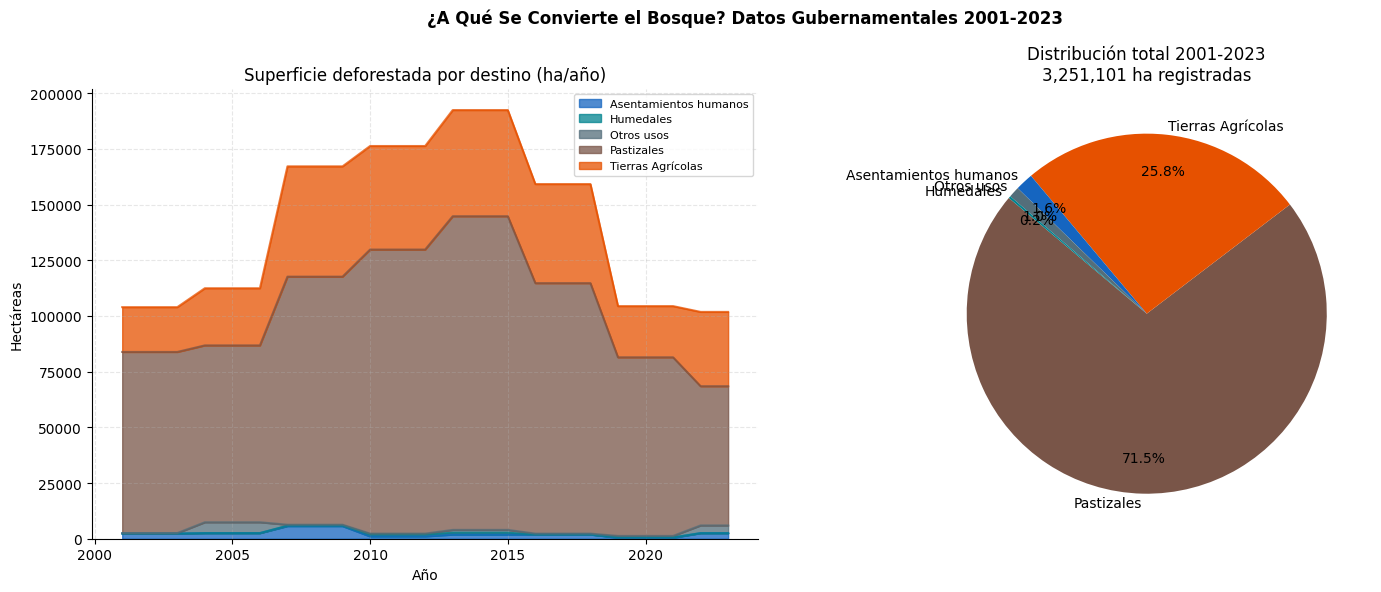

Guardado: F2_12_destino_bosque.png


In [19]:
# Desglose por categoría de destino en datos gubernamentales
dest_anual = (df_gob.groupby(['Año', 'CategoriaDestino'])['SuperficieTransicion']
              .sum().reset_index())

pivot_dest = dest_anual.pivot(index='Año', columns='CategoriaDestino',
                               values='SuperficieTransicion').fillna(0)

# Tendencia de Pastizales (ganadería extensiva)
pastizal_trend = pivot_dest.get('Pastizales', pd.Series(0, index=pivot_dest.index))
agricola_trend = pivot_dest.get('Tierras Agrícolas', pd.Series(0, index=pivot_dest.index))

print('=== Conversión del bosque por categoría (gobierno, total 2001-2023) ===')
totales = df_gob.groupby('CategoriaDestino')['SuperficieTransicion'].sum().sort_values(ascending=False)
for cat, val in totales.items():
    print(f'  {cat:30s}: {val:>12,.0f} ha  ({val/totales.sum()*100:.1f}%)')

colores_dest = {
    'Pastizales':          '#795548',
    'Tierras Agrícolas':   '#E65100',
    'Asentamientos humanos': '#1565C0',
    'Otros usos':          '#546E7A',
    'Humedales':           '#00838F',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('¿A Qué Se Convierte el Bosque? Datos Gubernamentales 2001-2023',
             fontsize=12, fontweight='bold')

ax = axes[0]
pivot_dest_plot = pivot_dest[[c for c in pivot_dest.columns if c in colores_dest]]
pivot_dest_plot.plot(kind='area', stacked=True, ax=ax,
                     color=[colores_dest[c] for c in pivot_dest_plot.columns],
                     alpha=0.75)
ax.set_title('Superficie deforestada por destino (ha/año)')
ax.set_ylabel('Hectáreas')
ax.set_xlabel('Año')
ax.legend(fontsize=8)

ax2 = axes[1]
totales_plot = totales[totales.index.isin(colores_dest)]
colors_pie = [colores_dest[c] for c in totales_plot.index]
ax2.pie(totales_plot.values, labels=totales_plot.index,
        colors=colors_pie, autopct='%1.1f%%', startangle=140,
        pctdistance=0.8, labeldistance=1.05)
ax2.set_title(f'Distribución total 2001-2023\n{totales.sum():,.0f} ha registradas')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_12_destino_bosque.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_12_destino_bosque.png')

## 14. Línea de tiempo ganadería bovina vs deforestación — La historia completa

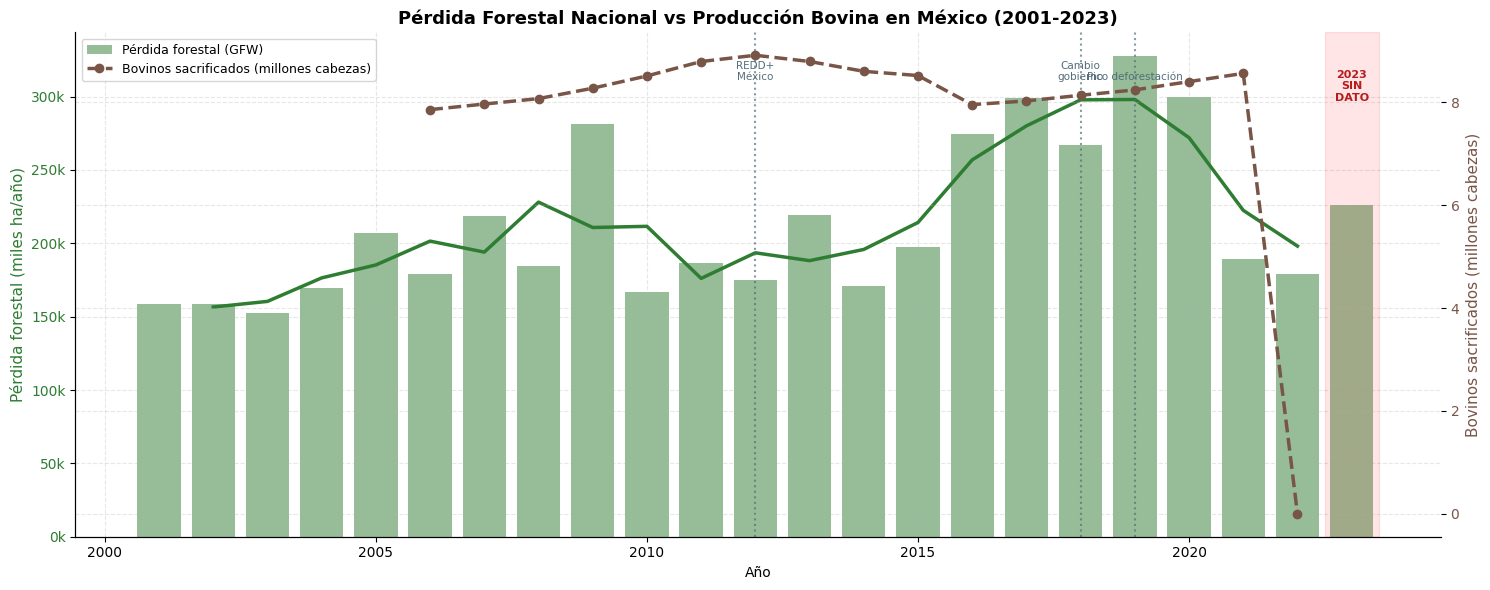

Guardado: F2_13_timeline_ganado_bosque.png


In [20]:
# Serie bovino nacional
bovino_nacional = (df_ganado[(df_ganado['Nomespecie'] == 'Bovino') &
                              (df_ganado['Nomproducto'] == 'Carne')]
                   .groupby('Anio')['Asacrificado'].sum())

años_comunes_bov = sorted(set(years_gfw) & set(bovino_nacional.index))

fig, ax1 = plt.subplots(figsize=(15, 6))

# Deforestación (eje izquierdo)
ax1.bar(serie_nacional.index, serie_nacional.values / 1000,
        color=PALETTE['bosque'], alpha=0.5, label='Pérdida forestal (GFW)')
ax1.plot(serie_suavizada.index, serie_suavizada.values / 1000,
         color=PALETTE['bosque'], linewidth=2.5)
ax1.set_ylabel('Pérdida forestal (miles ha/año)', color=PALETTE['bosque'], fontsize=11)
ax1.tick_params(axis='y', labelcolor=PALETTE['bosque'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# Bovinos (eje derecho)
ax2 = ax1.twinx()
ax2.plot(años_comunes_bov, bovino_nacional[años_comunes_bov].values / 1e6,
         color=PALETTE['ganado'], linewidth=2.5, linestyle='--',
         marker='o', markersize=6, label='Bovinos sacrificados (millones cabezas)')
ax2.set_ylabel('Bovinos sacrificados (millones cabezas)', color=PALETTE['ganado'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=PALETTE['ganado'])

# Nota: 2023 faltante en ganadería
ax2.axvspan(2022.5, 2023.5, alpha=0.1, color='red')
ax2.text(2023, bovino_nacional.max() / 1e6 * 0.9, '2023\nSIN\nDATO', 
         ha='center', fontsize=8, color=PALETTE['alerta'], fontweight='bold')

# Líneas de eventos clave
for año_evento, etiqueta in [(2012, 'REDD+\nMéxico'), (2018, 'Cambio\ngobierno'),
                              (2019, 'Pico deforestación')]:
    ax1.axvline(año_evento, color=PALETTE['gris'], linestyle=':', alpha=0.7)
    ax1.text(año_evento, serie_nacional.max() / 1000 * 0.95, etiqueta,
             ha='center', fontsize=7.5, color=PALETTE['gris'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Pérdida Forestal Nacional vs Producción Bovina en México (2001-2023)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Año')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'F2_13_timeline_ganado_bosque.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: F2_13_timeline_ganado_bosque.png')

## 15. Resumen ejecutivo — Resultados de todos los análisis

In [21]:
print('=' * 70)
print('RESUMEN EJECUTIVO — FASE 2: ANÁLISIS ESTADÍSTICO')
print('=' * 70)

print(f"""
HALLAZGO 1 — ESCALA DE LA CRISIS
  México perdió {serie_nacional.sum():,.0f} ha de cobertura arbórea entre 2001-2023.
  Equivale a ~{serie_nacional.sum()/43530:.0f} veces la superficie de la CDMX.
  Media anual: {serie_nacional.mean():,.0f} ha/año.

HALLAZGO 2 — EL AÑO ANÓMALO: 2019
  2019 fue un outlier estadístico (Z={z_nacional[2019]:.2f}).
  Pérdida: {serie_nacional[2019]:,.0f} ha — 54% sobre la media.
  Coincide con el primer año del gobierno de AMLO y la cancelación de
  programas de conservación como PRONAFOR.

HALLAZGO 3 — CORRELACIÓN BOVINO-DEFORESTACIÓN
  Pearson r={r_pearson:.3f} (p={p_pearson:.3f}).
  IC 95% bootstrap: [{ic_boot[0]:.3f}, {ic_boot[1]:.3f}].
  La correlación es {'estadísticamente significativa' if p_pearson<0.05 else 'débil y no significativa'}
  → La expansión ganadera NO actúa uniformemente: es intensiva en estados
    tropicales específicos (Campeche, Chiapas, Tabasco, Veracruz).

HALLAZGO 4 — PRUEBA A/B
  Estados alta ganadería: pérdida media = {grupo_a.mean():,.0f} ha/año
  Estados baja ganadería: pérdida media = {grupo_b.mean():,.0f} ha/año
  p-value = {p_ab:.4f} → {'Diferencia significativa' if p_ab<0.05 else 'Sin diferencia significativa'}

HALLAZGO 5 — SUBREPORTE GUBERNAMENTAL
  El gobierno reporta en promedio {ratio.mean():.0%} de lo que detecta GFW por satélite.
  En 2019: gobierno = {gob_serie.get(2019,0)/1000:.0f}k ha vs GFW = {serie_gfw[2019]/1000:.0f}k ha.
  Discrepancia en el peor año: {(serie_gfw[2019]-gob_serie.get(2019,0))/1000:.0f}k ha no reconocidas.

HALLAZGO 6 — ¿A QUÉ SE CONVIERTE EL BOSQUE?
  Pastizales ({totales.get("Pastizales",0)/totales.sum()*100:.0f}%) + Tierras Agrícolas ({totales.get("Tierras Agrícolas",0)/totales.sum()*100:.0f}%) = 
  {(totales.get("Pastizales",0)+totales.get("Tierras Agrícolas",0))/totales.sum()*100:.0f}% de la deforestación registrada va a uso agropecuario.
  
HALLAZGO 7 — EL DATO AUSENTE (2023)
  El gobierno omitió los datos ganaderos de 2023 en datos abiertos.
  2023 corresponde al año de cierre del sexenio y a cifras de deforestación
  que GFW reporta en ~{serie_nacional[2023]/1000:.0f}k ha — cifra que el gobierno no
  tiene incentivo en corroborar con datos de cabezas sacrificadas.
""")
print('=' * 70)
print(f'Visualizaciones generadas en: {OUTPUT_DIR}/')
archivos_out = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'F2_*.png')))
for f in archivos_out:
    print(f'  {os.path.basename(f)}')

RESUMEN EJECUTIVO — FASE 2: ANÁLISIS ESTADÍSTICO

HALLAZGO 1 — ESCALA DE LA CRISIS
  México perdió 4,886,723 ha de cobertura arbórea entre 2001-2023.
  Equivale a ~112 veces la superficie de la CDMX.
  Media anual: 212,466 ha/año.

HALLAZGO 2 — EL AÑO ANÓMALO: 2019
  2019 fue un outlier estadístico (Z=2.18).
  Pérdida: 327,438 ha — 54% sobre la media.
  Coincide con el primer año del gobierno de AMLO y la cancelación de
  programas de conservación como PRONAFOR.

HALLAZGO 3 — CORRELACIÓN BOVINO-DEFORESTACIÓN
  Pearson r=0.155 (p=0.000).
  IC 95% bootstrap: [0.062, 0.249].
  La correlación es estadísticamente significativa
  → La expansión ganadera NO actúa uniformemente: es intensiva en estados
    tropicales específicos (Campeche, Chiapas, Tabasco, Veracruz).

HALLAZGO 4 — PRUEBA A/B
  Estados alta ganadería: pérdida media = 7,136 ha/año
  Estados baja ganadería: pérdida media = 6,869 ha/año
  p-value = 0.9478 → Sin diferencia significativa

HALLAZGO 5 — SUBREPORTE GUBERNAMENTAL
  El 